# Experiment 03: Spatial Lag


In [124]:
import numpy as np

In [2]:
import pandas as pd
import geopandas as gpd

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
import folium
from folium import Marker, Circle

In [15]:
from sklearn.neighbors import NearestNeighbors

In [17]:
from libpysal.weights import KNN

In [19]:
from libpysal.weights import lag_spatial

In [99]:
import contextily as ctx

In [7]:
df = pd.read_csv('../../data/processed/housing_cleaned.csv')

In [8]:
gdf = gpd.GeoDataFrame(
    df, 
    geometry=gpd.points_from_xy(df['longitude'], df['latitude']),
    crs="EPSG:4326"
)

In [9]:
gdf_utm = gdf.to_crs("EPSG:32618")

In [10]:
# Extract UTM coordinates for spatial analysis
gdf_utm['x_utm'] = gdf_utm.geometry.x
gdf_utm['y_utm'] = gdf_utm.geometry.y

Text(0.5, 1.0, 'NYC Housing Prices')

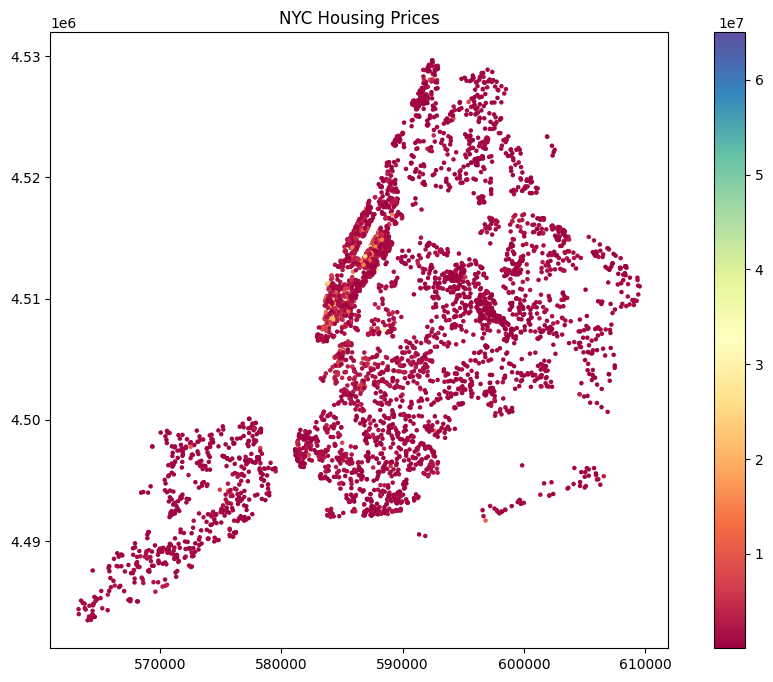

In [14]:
gdf_utm.plot(column="price", 
         figsize=(12, 8),
         legend=True,
         cmap="Spectral",
         markersize=5)
plt.title("NYC Housing Prices")

Text(0.5, 1.0, 'NYC Housing Prices (log scale)')

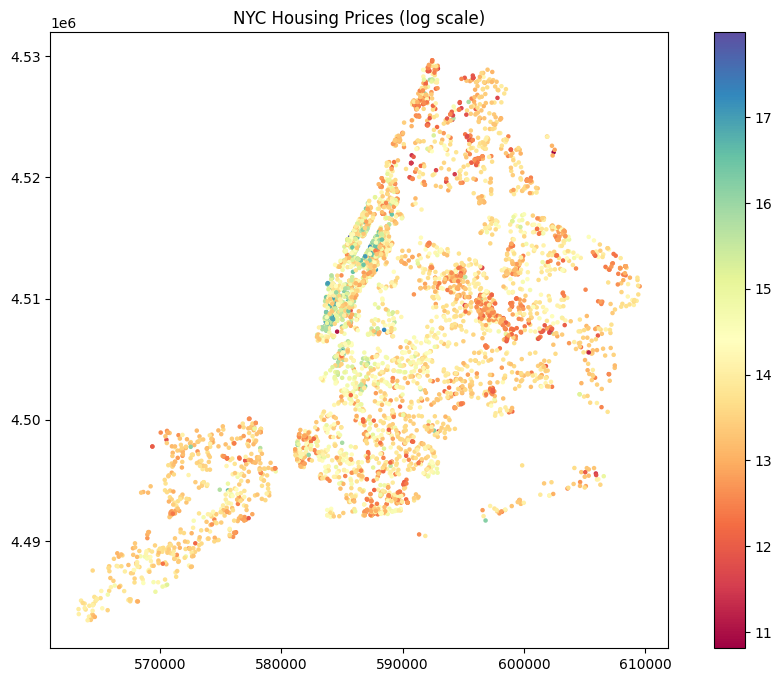

In [13]:
gdf_utm.plot(column="log_price", 
         figsize=(12, 8),
         legend=True,
         cmap="Spectral",
         markersize=5)
plt.title("NYC Housing Prices (log scale)")

In [88]:
# Попробую spatial lag для цен

In [18]:
w = KNN.from_dataframe(gdf_utm, k=5)
w.transform = 'R'

C:\Users\gis\.virtualenvs\task2_git-NJPCFo58\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 9 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


In [20]:
# для начала возьму 5 nearest neighbours
gdf_utm['lag_price_knn_k5'] = lag_spatial(w, gdf_utm['price'])

Text(0.5, 1.0, 'lag_price_knn_k5')

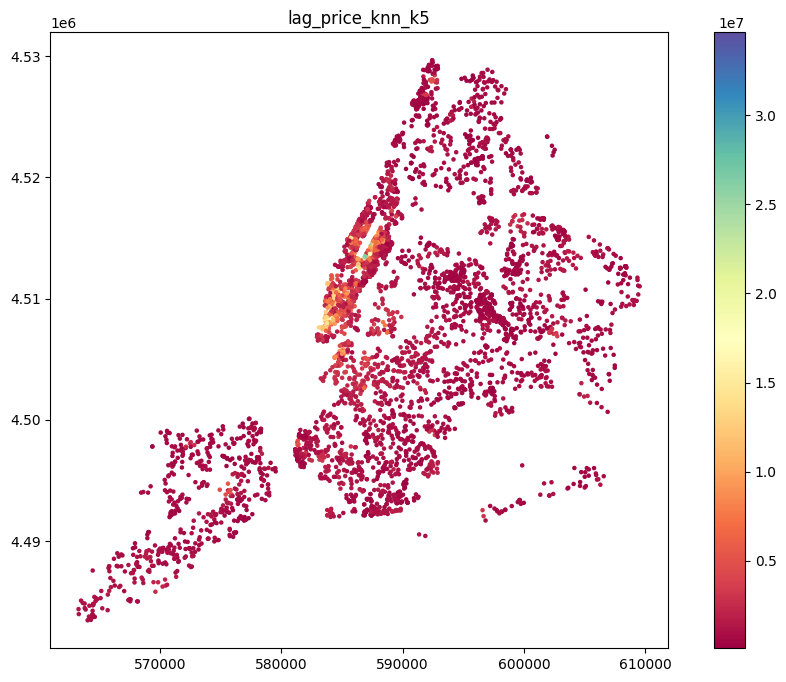

In [21]:
gdf_utm.plot(column="lag_price_knn_k5", 
         figsize=(12, 8),
         legend=True,
         cmap="Spectral",
         markersize=5)
plt.title("lag_price_knn_k5")

In [90]:
# Ну ок, но не впечатляет
# Возьмем 25 nearest neighbours

In [22]:
w = KNN.from_dataframe(gdf_utm, k=25)
w.transform = 'R'

C:\Users\gis\.virtualenvs\task2_git-NJPCFo58\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


In [23]:
gdf_utm['lag_price_knn_k25'] = lag_spatial(w, gdf_utm['price'])

Text(0.5, 1.0, 'lag_price_knn_k25')

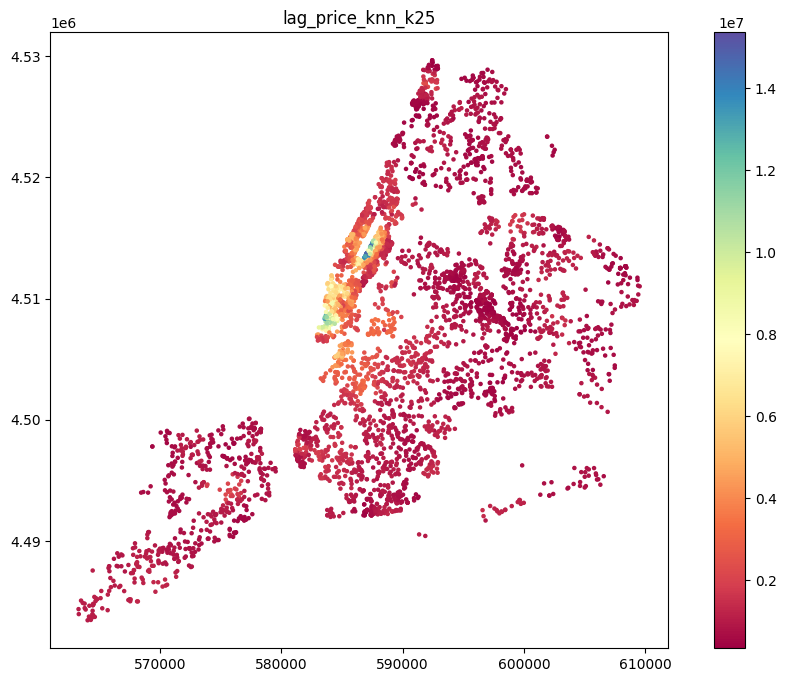

In [24]:
gdf_utm.plot(column="lag_price_knn_k25", 
         figsize=(12, 8),
         legend=True,
         cmap="Spectral",
         markersize=5)
plt.title("lag_price_knn_k25")

In [91]:
# Ну вот центры дорогой недвижимости обозначились
# Попробуем еще больше радикализировать

In [25]:
w = KNN.from_dataframe(gdf_utm, k=50)
w.transform = 'R'

In [26]:
gdf_utm['lag_price_knn_k50'] = lag_spatial(w, gdf_utm['price'])

Text(0.5, 1.0, 'lag_price_knn_k50')

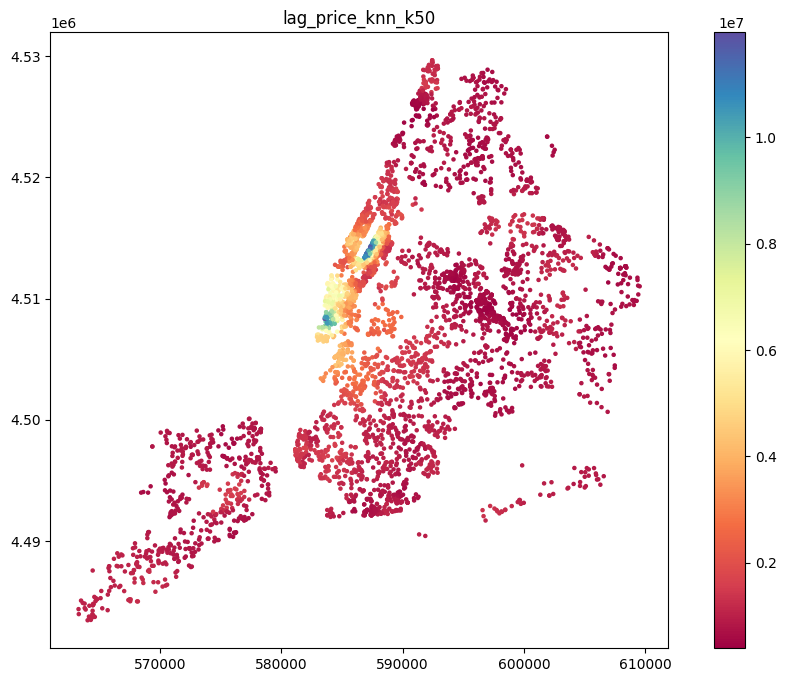

In [27]:
gdf_utm.plot(column="lag_price_knn_k50", 
         figsize=(12, 8),
         legend=True,
         cmap="Spectral",
         markersize=5)
plt.title("lag_price_knn_k50")

In [28]:
w = KNN.from_dataframe(gdf_utm, k=100)
w.transform = 'R'

In [29]:
gdf_utm['lag_price_knn_k100'] = lag_spatial(w, gdf_utm['price'])

Text(0.5, 1.0, 'lag_price_knn_k100')

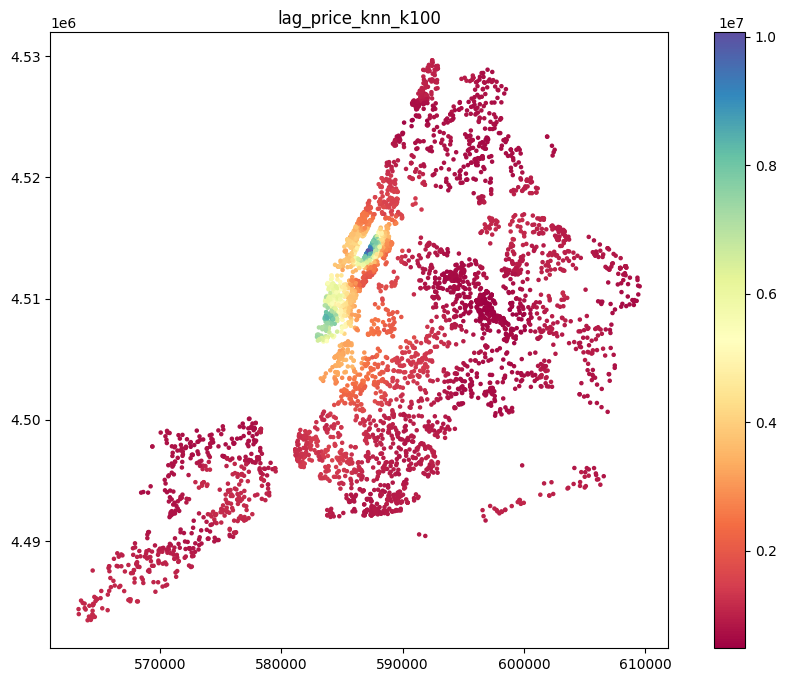

In [30]:
gdf_utm.plot(column="lag_price_knn_k100", 
         figsize=(12, 8),
         legend=True,
         cmap="Spectral",
         markersize=5)
plt.title("lag_price_knn_k100")

In [34]:
w = KNN.from_dataframe(gdf_utm, k=200)
w.transform = 'R'

In [35]:
gdf_utm['lag_price_knn_k200'] = lag_spatial(w, gdf_utm['price'])

[]

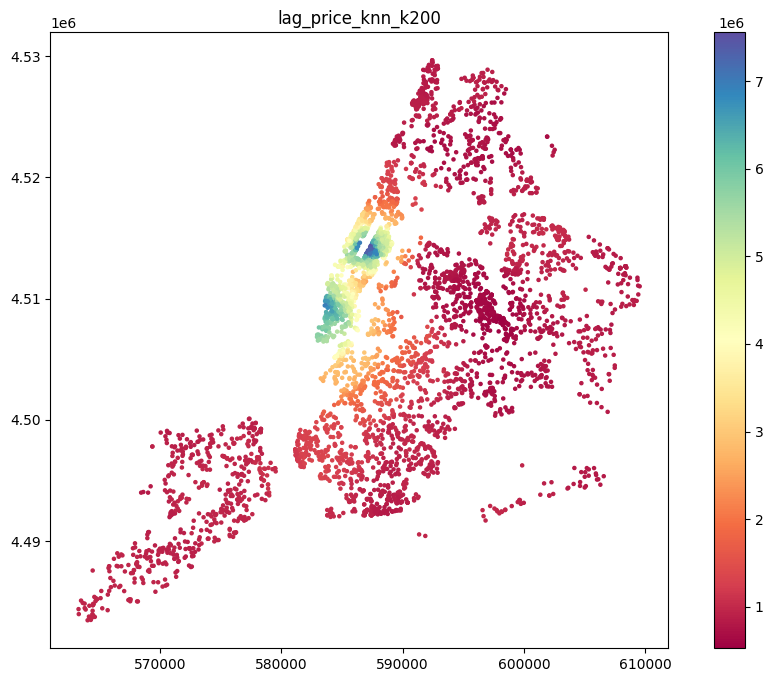

In [37]:
gdf_utm.plot(column="lag_price_knn_k200", 
         figsize=(12, 8),
         legend=True,
         cmap="Spectral",
         markersize=5)
plt.title("lag_price_knn_k200")

In [92]:
# Очень наглядно и выпукло обозначились ценовые пики
# Посмотрим выделится ли так же по низам

In [56]:
low = gdf_utm[gdf_utm['lag_price_knn_k200'] < gdf_utm['lag_price_knn_k200'].quantile(0.5)]

Text(0.5, 1.0, 'lag_price_knn_k200')

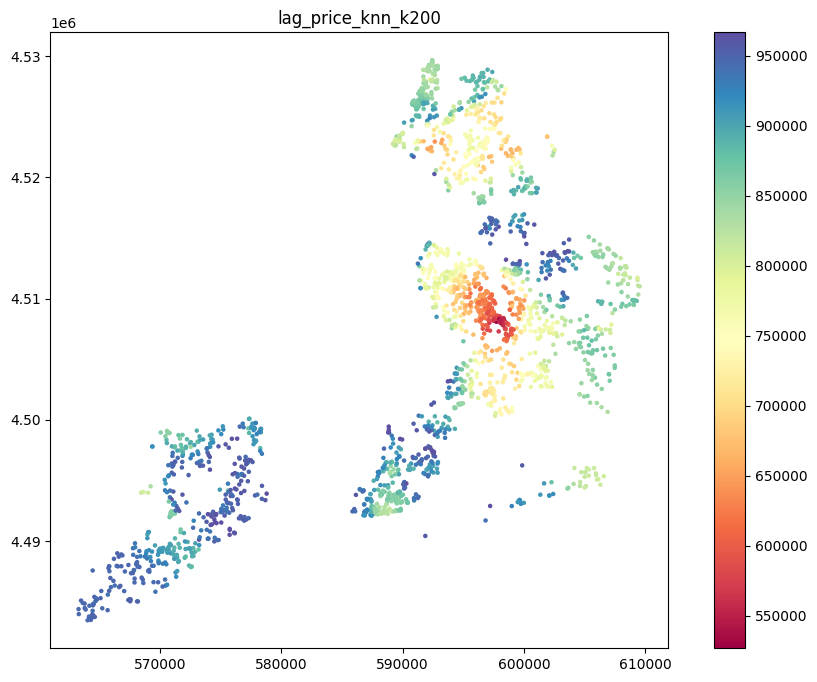

In [57]:
low.plot(column="lag_price_knn_k200", 
         figsize=(12, 8),
         legend=True,
         cmap="Spectral",
         markersize=5)
plt.title("lag_price_knn_k200")

In [93]:
# Тоже нормально все читается

In [95]:
# Посмотрим на относительный цены - во сколько раз реальная стоимость превосходит ценовой лаг
# То есть сначала посчитали среднюю цену ближайших объектов для каждой строки
# а потом поделили стоимость объекта на среднюю стоимость по соседям

In [61]:
gdf_utm['relative_price_k200'] = gdf_utm['price']/gdf_utm['lag_price_knn_k200']

Text(0.5, 1.0, 'relative_price_k200')

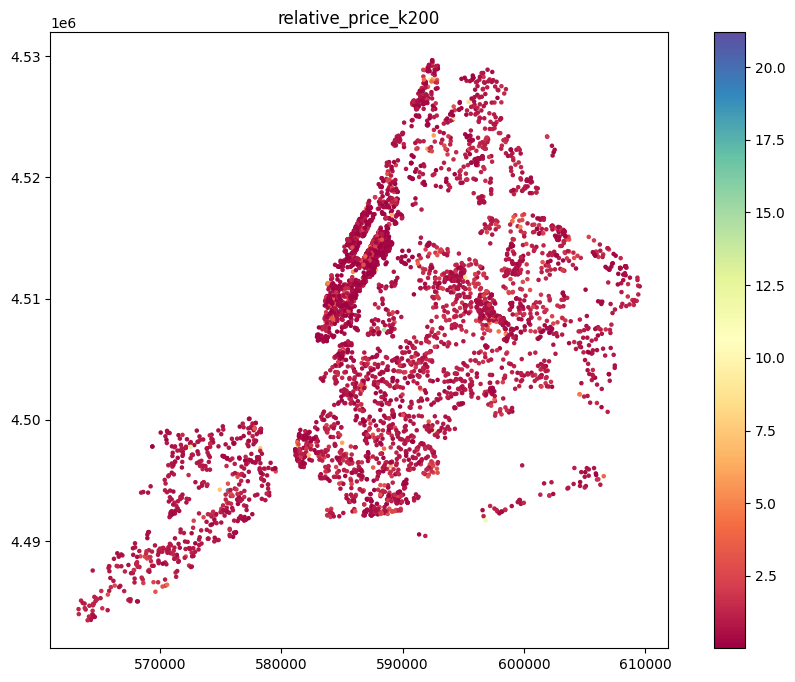

In [96]:
gdf_utm.plot(column="relative_price_k200", 
         figsize=(12, 8),
         legend=True,
         cmap="Spectral",
         markersize=5)
plt.title("relative_price_k200")

In [ ]:
# Ничего не видно толком

In [64]:
# Посмотрим что там получилось с относительной ценой
gdf_utm['relative_price_k200'].describe()

count    4582.000000
mean        0.956460
std         1.136674
min         0.012031
25%         0.349650
50%         0.713875
75%         1.163454
max        21.197691
Name: relative_price_k200, dtype: float64

In [ ]:
# Ну понятно по максимуму в 21 раз превосходит реальная цена ценовой лаг

In [97]:
gdf_utm['relative_price_k25'] = gdf_utm['price']/gdf_utm['lag_price_knn_k25']

In [98]:
gdf_utm['relative_price_k25'].describe()

count    4582.000000
mean        1.044292
std         1.317197
min         0.010316
25%         0.435298
50%         0.791261
75%         1.233657
max        36.661239
Name: relative_price_k25, dtype: float64

In [ ]:
# С относительной стоимостью по 25 соседям примерно тоже самое

In [86]:
rel_90_k25 = gdf_utm[gdf_utm['relative_price_k25'] < gdf_utm['relative_price_k25'].quantile(0.9)]

Text(0.5, 1.0, 'relative_price_k25')

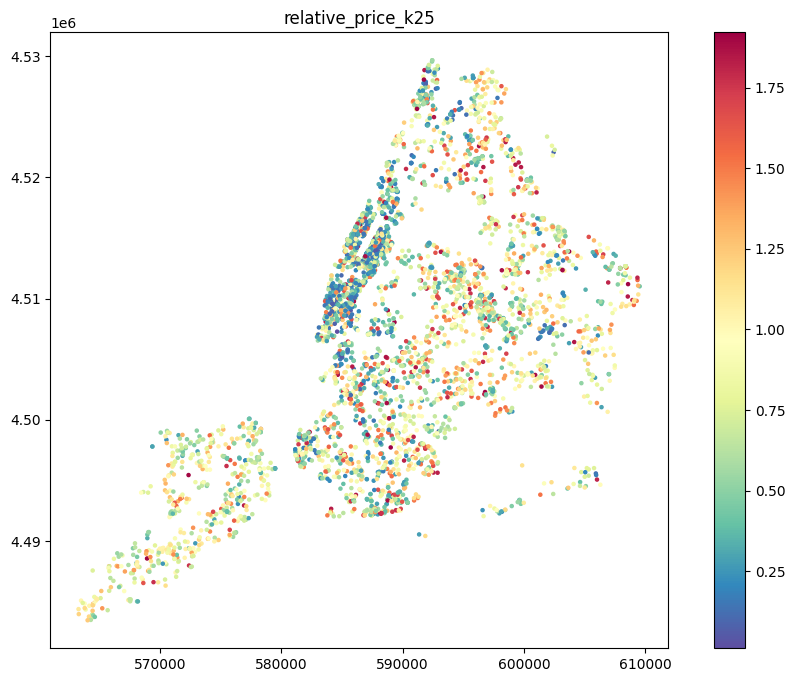

In [121]:
rel_90_k25.plot(column="relative_price_k25", 
         figsize=(12, 8),
         legend=True,
         cmap="Spectral_r",
         markersize=5)
plt.title("relative_price_k25")

In [81]:
w = KNN.from_dataframe(rel_90, k=200)
w.transform = 'R'

In [82]:
rel_90['rel_price_lag_knn_k200'] = lag_spatial(w, rel_90['relative_price_k200'])

Text(0.5, 1.0, 'rel_price_lag_knn_k200')

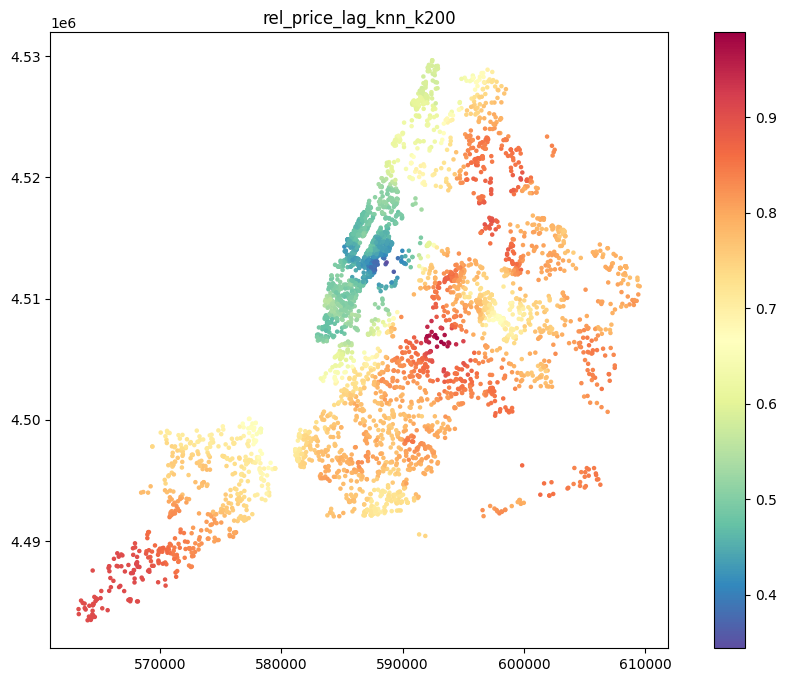

In [84]:
rel_90.plot(column="rel_price_lag_knn_k200", 
         figsize=(12, 8),
         legend=True,
         cmap="Spectral_r",
         markersize=5)
plt.title("rel_price_lag_knn_k200")

In [118]:
w = KNN.from_dataframe(rel_90, k=25)
w.transform = 'R'

C:\Users\gis\.virtualenvs\task2_git-NJPCFo58\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


In [119]:
rel_90['rel_price_lag_knn_k25'] = lag_spatial(w, rel_90['relative_price_k25'])

Text(0.5, 1.0, 'rel_price_lag_knn_k25')

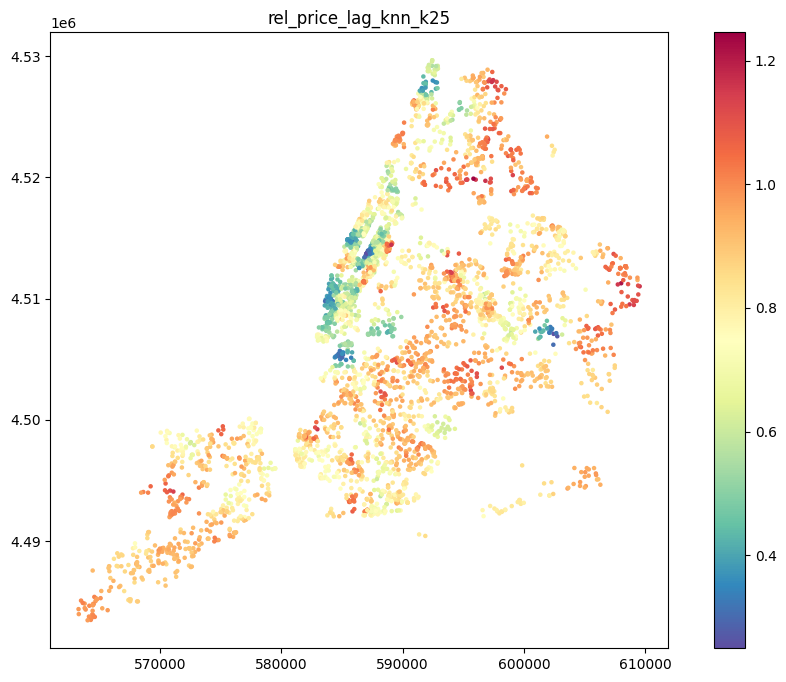

In [120]:
rel_90.plot(column="rel_price_lag_knn_k25", 
         figsize=(12, 8),
         legend=True,
         cmap="Spectral_r",
         markersize=5)
plt.title("rel_price_lag_knn_k25")

In [122]:
w = KNN.from_dataframe(gdf_utm, k=200)

In [125]:
prices = gdf_utm["price"].values
neighbors = w.neighbors

lag_median = np.zeros(len(prices))

for i in range(len(prices)):
    neighbor_ids = neighbors[i]
    lag_median[i] = np.median(prices[neighbor_ids])

gdf_utm["lag_price_median_k200"] = lag_median

Text(0.5, 1.0, 'lag_price_median_k200')

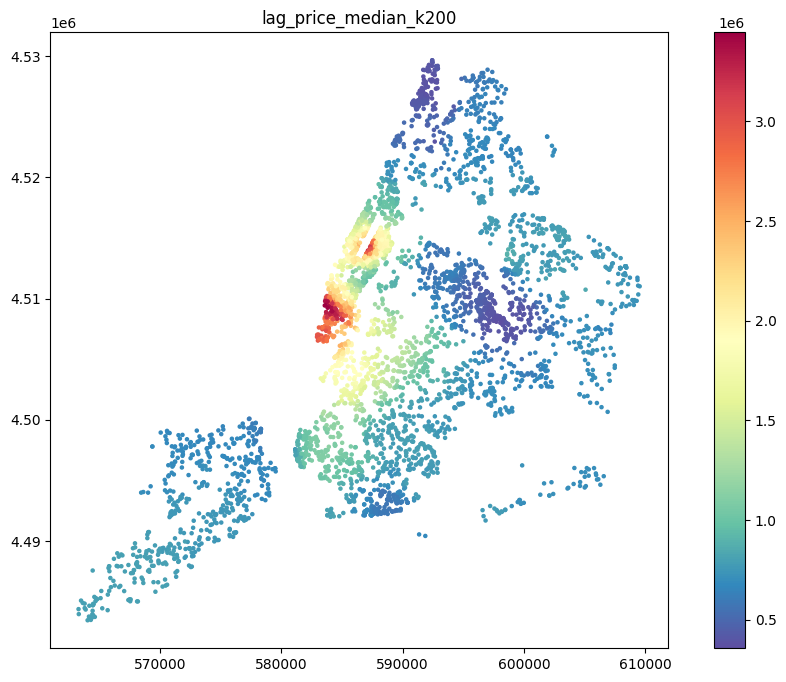

In [126]:
gdf_utm.plot(column="lag_price_median_k200", 
         figsize=(12, 8),
         legend=True,
         cmap="Spectral_r",
         markersize=5)
plt.title("lag_price_median_k200")

In [127]:
low = gdf_utm[gdf_utm['lag_price_median_k200'] < gdf_utm['lag_price_median_k200'].quantile(0.5)]

Text(0.5, 1.0, 'lag_price_median_k200')

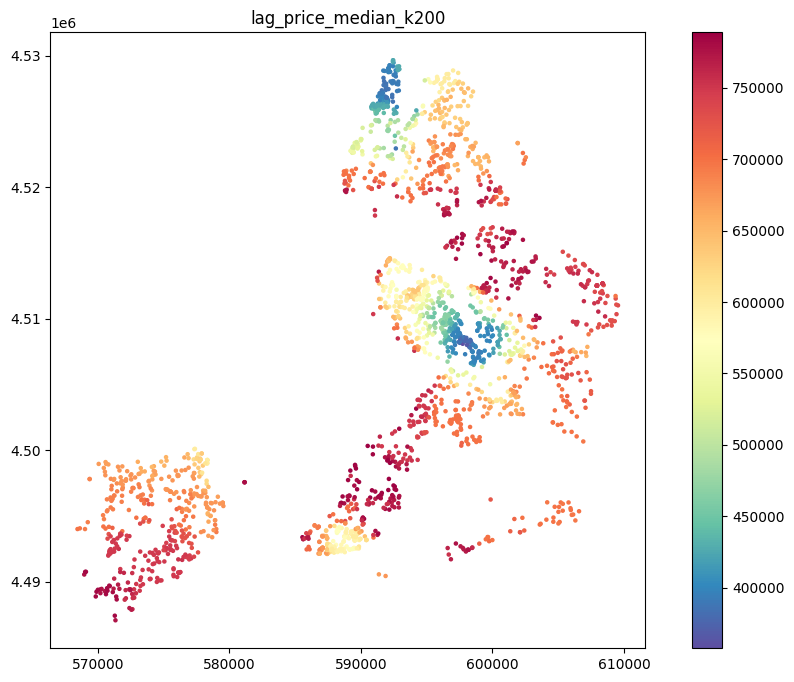

In [128]:
low.plot(column="lag_price_median_k200", 
         figsize=(12, 8),
         legend=True,
         cmap="Spectral_r",
         markersize=5)
plt.title("lag_price_median_k200")